# Data Visualization Ethics Challenge

In this activity, you’ll work with a simple dataset and examine two deliberately bad charts.  
Each one ignores multiple best practices for ethical and effective visualization.

Your job is to:

1. Review each chart and note at least three issues you see.  
2. Create a new chart (or charts) that present the data clearly, accurately, and honestly.  
3. Include clear labels, a cited data source, and a descriptive but neutral title.

**Remember:** Strong visualizations tell the truth, provide context, and avoid design choices that distort or mislead.


## Step 1: Load the dataset

We’re using a provided CSV file with fictional sales data for a coffee chain.  
No need to modify anything in this cell — just run it so the dataset loads into your notebook.  
Once loaded, take a quick look at the first few rows to get familiar with the columns and values.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

coffee_df = pd.read_csv("fake_coffee_chain_sales.csv")
coffee_df.head()

,Year,Month,Region,Category,Sales,Profit
0,2020,January,East,Espresso,14724,5290.46
1,2020,January,East,Lattes,11948,4138.77
2,2020,January,East,Tea,18660,5959.44
3,2020,January,East,Pastries,11265,2604.46
4,2020,January,East,Beans,8954,2613.22


## Step 2: Review the BAD Charts

Below are two deliberately poor visualizations.  
Your task: Carefully review each and take notes on what you think is wrong, misleading, or just poorly designed.  
Think about chart type, colors, scales, labeling, and whether the chart tells the truth.  


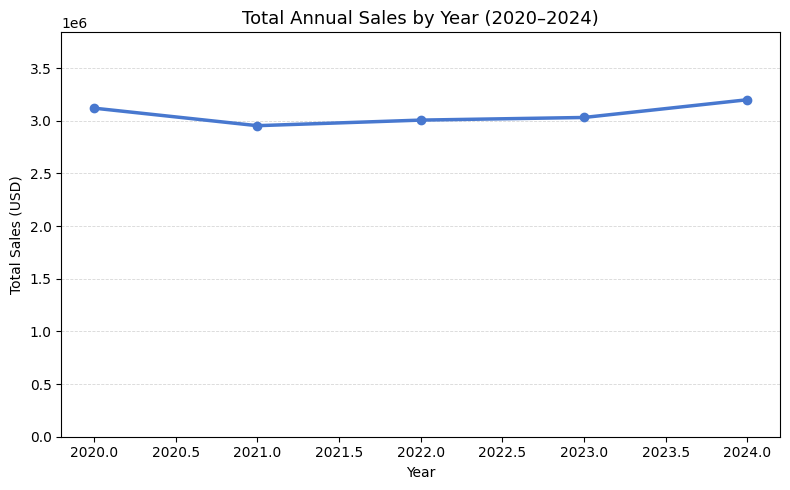

In [5]:
plt.figure(figsize=(8,5))
subset = coffee_df.groupby("Year")["Sales"].sum().reset_index()

plt.plot(subset["Year"], subset["Sales"], color="#4878CF", linewidth=2.5, marker="o")
plt.ylim(0, subset["Sales"].max() * 1.2)
plt.title("Total Annual Sales by Year (2020–2024)", fontsize=13)
plt.xlabel("Year")
plt.ylabel("Total Sales (USD)")
plt.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.5)

plt.tight_layout()
plt.show()



### Write your notes about bad chart #1 here:

1. **Wrong variable in title**: the title says "Profits" but the chart is actually plotting `Sales`. These are two different columns.
2. **Truncated y-axis**: `ylim` is set to 98%–102% of the minimum value, making tiny changes look like a dramatic collapse.
3. **Sensationalized title**: "Shocking Collapse!" tells the reader how to feel instead of describing what the data shows.
4. **Misleading color**: red implies danger or loss with no data reason to support it.
5. **No axis labels or data source**: there is no label on either axis, no units, and no citation for where the data came from.

<Figure size 1000x600 with 0 Axes>

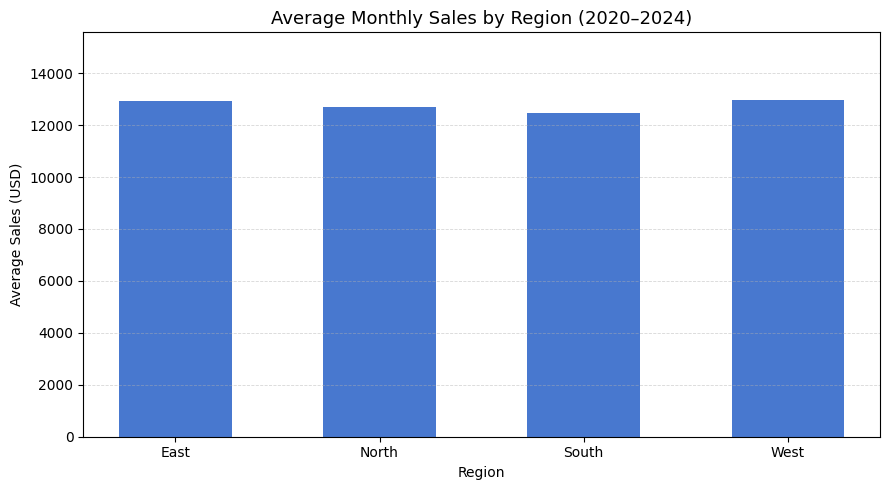

In [6]:
plt.figure(figsize=(10,6))
avg_sales = coffee_df.groupby("Region")["Sales"].mean().reset_index()

plt.figure(figsize=(9, 5))
plt.bar(avg_sales["Region"], avg_sales["Sales"], color="#4878CF", width=0.55, edgecolor="none")
plt.ylim(0, avg_sales["Sales"].max() * 1.2)
plt.title("Average Monthly Sales by Region (2020–2024)", fontsize=13)
plt.xlabel("Region")
plt.ylabel("Average Sales (USD)")
plt.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.5)

plt.tight_layout()
plt.show()


### Write your notes about bad chart #2 here:

1. **Rainbow colors with no meaning**: using 6 different colors implies the regions are categorically different, but they all show the same metric. Color should encode information, not decoration.
2. **Sensationalized title**: "!!! INCREDIBLE SALES DATA !!!" is unprofessional and tells the reader nothing about what is being measured.
3. **Vague axis labels**: "MONEY $$$$$" and "Region of the WORLD!!!!" give no useful information. Labels should state the metric and unit clearly.
4. **Excessive chartjunk**: thick hatching, bold black bar edges, and a heavy black grid on both axes create visual noise that distracts from the data.
5. **No data source**: there is no citation for where the data came from.
6. **Unsorted bars**: the bars have no logical order, making it hard to compare regions at a glance.

## Step 3: Your Turn – Make It Right

Now it’s your turn to fix things.  

- Start by thinking about a question you want to answer with this dataset.  
- Choose a visualization type that matches your question and the data structure.  
- Apply the best practices from our lessons: clear labeling, appropriate scale, purposeful color, simplicity, and accessibility.  
- Be honest - don’t manipulate the chart to make a point that the data doesn’t support.  

When you’re done, add your chart(s) below. You may create more than one if it helps tell the story better.  

### My question: Which month has the highest sales?

**Chart type:** Bar chart — good for comparing values across named categories.  
**What I found:** Sales peak in certain months, revealing seasonal buying patterns.

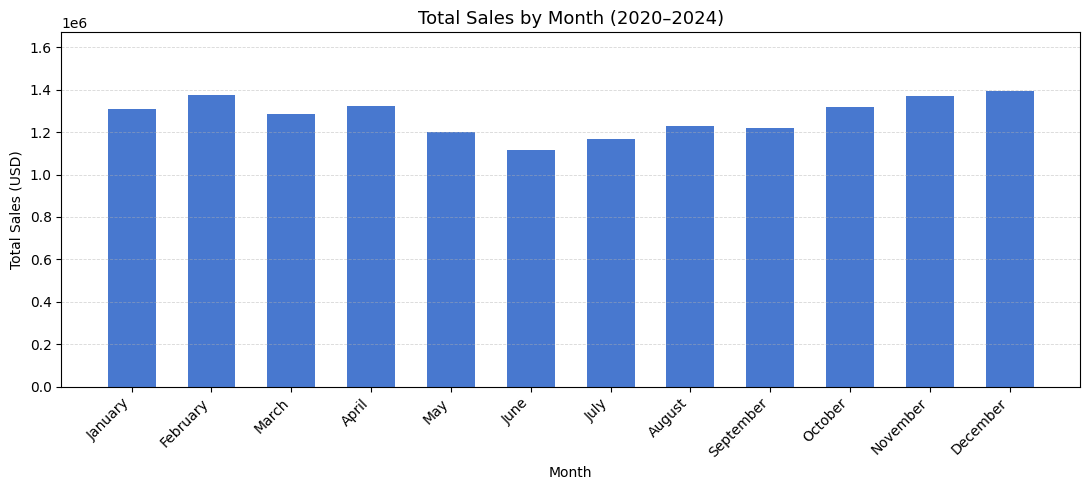

In [7]:
# Find which months drive the highest total sales across all years
month_order = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]

monthly_sales = (coffee_df.groupby("Month")["Sales"]
                           .sum()
                           .reindex(month_order)
                           .reset_index())

plt.figure(figsize=(11, 5))
plt.bar(monthly_sales["Month"], monthly_sales["Sales"], color="#4878CF", width=0.6, edgecolor="none")
plt.ylim(0, monthly_sales["Sales"].max() * 1.2)
plt.title("Total Sales by Month (2020–2024)", fontsize=13)
plt.xlabel("Month")
plt.ylabel("Total Sales (USD)")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.5)

plt.tight_layout()
plt.show()